# CS610 Assignment 1 Q5: Twitter Bot Detection
**Task:** Binary classification, distinguish bot accounts (target=1) from genuine users (target=0).  
**Metric:** AUC (Area Under ROC Curve)

## 1. Setup & Imports

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost optuna

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import roc_curve

from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import r2_score

from scipy.stats import rankdata

import optuna

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
train.head(3)

Train shape : (26206, 19)
Test shape  : (11232, 19)


,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,target
0,2012-01-15 23:40:09,True,False,Cosplayer/Fitness lover. Come to me https://t....,74,7,0,False,465096524,en,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9666745212...,reml5477,20,False,0.006,3138,1
1,2016-10-04 00:44:39,False,False,pobody’s nerfect,50443,164,590,True,783105517673648132,cy,she/her,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1281752126...,kinlibra,6469,False,4.572,1415,0
2,2009-05-23 04:04:13,False,False,gracias por participar 🏅,9394,208,189,False,41970759,es,La diaspora,http://abs.twimg.com/images/themes/theme17/bg.gif,http://pbs.twimg.com/profile_images/1233811596...,_delaualau,30296,False,7.378,4106,0


## 3. Exploratory Data Analysis

In [4]:
# --- Target distribution ---
print('Target distribution (train):')
print(train['target'].value_counts())
print(f'Bot rate: {train["target"].mean():.2%}')

8783/(8783+17423)

Target distribution (train):
target
0    17423
1     8783
Name: count, dtype: int64
Bot rate: 33.52%


0.3351522552087308

In [4]:
train.describe()

,favourites_count,followers_count,friends_count,id,statuses_count,average_tweets_per_day,account_age_days,target
count,26206.000000,2.620600e+04,2.620600e+04,2.620600e+04,2.620600e+04,26206.000000,26206.000000,26206.000000
mean,12159.971342,3.732983e+05,4.427275e+03,1.253306e+17,2.072485e+04,6.754636,3017.870831,0.335152
std,33628.948536,2.515996e+06,4.602204e+04,3.035728e+17,6.345569e+04,22.782745,1018.958572,0.472053
min,0.000000,0.000000e+00,0.000000e+00,5.860000e+02,0.000000e+00,0.000000,483.000000,0.000000
25%,347.000000,3.400000e+01,3.400000e+01,9.799366e+07,1.331000e+03,0.486250,2302.000000,0.000000
50%,2037.000000,3.540000e+02,2.920000e+02,3.997210e+08,4.143500e+03,1.464000,3218.000000,0.000000
75%,8751.750000,8.241500e+03,8.780000e+02,2.480241e+09,1.679150e+04,5.460000,3895.000000,1.000000
max,839929.000000,1.216415e+08,1.641962e+06,1.120974e+18,2.771910e+06,1191.286000,5151.000000,1.000000


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 26206 entries, 0 to 26205
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   created_at                    26206 non-null  str    
 1   default_profile               26206 non-null  bool   
 2   default_profile_image         26206 non-null  bool   
 3   description                   21115 non-null  str    
 4   favourites_count              26206 non-null  int64  
 5   followers_count               26206 non-null  int64  
 6   friends_count                 26206 non-null  int64  
 7   geo_enabled                   26206 non-null  bool   
 8   id                            26206 non-null  int64  
 9   lang                          20618 non-null  str    
 10  location                      26204 non-null  str    
 11  profile_background_image_url  22971 non-null  str    
 12  profile_image_url             26205 non-null  str    
 13  screen_name 

In [6]:
# --- Missing values ---
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values (train):')
print(missing)

Columns with missing values (train):
lang                            5588
description                     5091
profile_background_image_url    3235
location                           2
profile_image_url                  1
dtype: int64


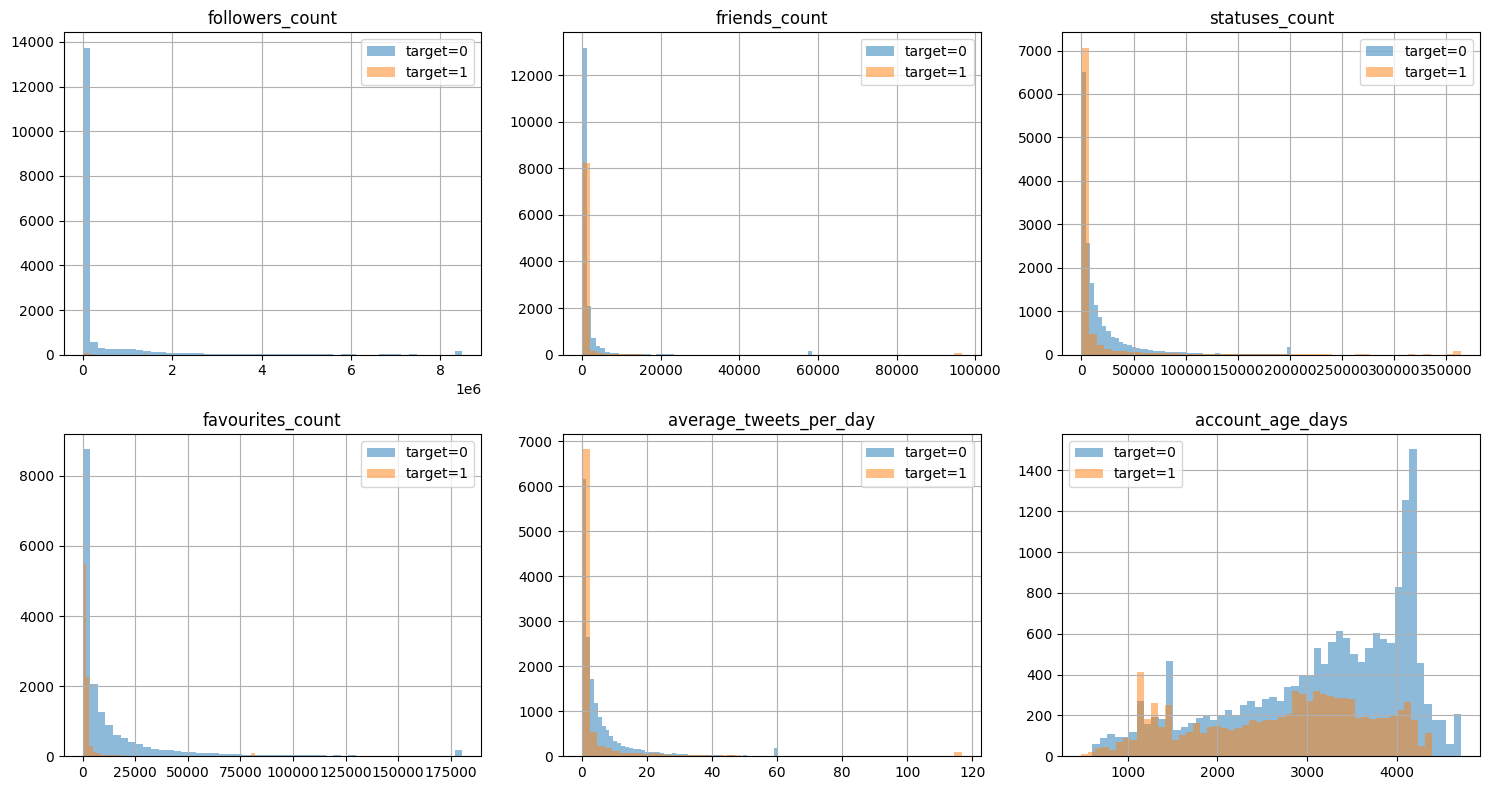

In [7]:
# --- Numeric feature distributions by class ---
numeric_cols = ['followers_count', 'friends_count', 'statuses_count',
                'favourites_count', 'average_tweets_per_day', 'account_age_days']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    for label, grp in train.groupby('target'):
        grp[col].clip(upper=grp[col].quantile(0.99)).hist(
            bins=50, ax=ax, alpha=0.5, label=f'target={label}')
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# --- Boolean feature bot rates ---
bool_cols = ['default_profile', 'default_profile_image', 'geo_enabled', 'verified']
for col in bool_cols:
    rate = train.groupby(col)['target'].mean()
    print(f'{col}:\n{rate}\n')

default_profile:
default_profile
False    0.218076
True     0.496059
Name: target, dtype: float64

default_profile_image:
default_profile_image
False    0.329861
True     0.689119
Name: target, dtype: float64

geo_enabled:
geo_enabled
False    0.479769
True     0.159195
Name: target, dtype: float64

verified:
verified
False    0.409719
True     0.040951
Name: target, dtype: float64



## 4. Feature Engineering

In [5]:
def feature_engineer(df):
    df = df.copy()

    # ---- Date/time features ----
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
    df['account_hour']      = df['created_at'].dt.hour
    df['account_dayofweek'] = df['created_at'].dt.dayofweek 
    df['account_year']      = df['created_at'].dt.year

    # ---- Ratio features ----
    eps = 1e-6
    df['followers_friends_ratio'] = df['followers_count'] / (df['friends_count']    + eps)
    df['friends_followers_ratio'] = df['friends_count']   / (df['followers_count']  + eps)
    df['tweet_per_follower']      = df['statuses_count']  / (df['followers_count']  + eps)
    df['favourite_per_follower']  = df['favourites_count']/ (df['followers_count']  + eps)
    df['tweet_per_age']           = df['statuses_count']  / (df['account_age_days'] + eps)
    df['favourite_per_age']       = df['favourites_count']/ (df['account_age_days'] + eps)
    df['followers_per_age']       = df['followers_count'] / (df['account_age_days'] + eps)
    df['friends_per_age']         = df['friends_count']   / (df['account_age_days'] + eps)

    # ---- Description features ----
    df['description_length']   = df['description'].fillna('').str.len()
    df['has_description']      = (df['description'].notna() & (df['description'] != '')).astype(int)
    df['description_word_cnt'] = df['description'].fillna('').str.split().str.len()
    df['has_url_in_desc']      = df['description'].fillna('').str.contains('http', case=False).astype(int)


    # New text features:
    df['desc_has_emoji']         = df['description'].fillna('').str.contains('[^\x00-\x7F]').astype(int)
    df['desc_special_char_cnt']  = df['description'].fillna('').str.count(r'[^a-zA-Z0-9\s]')

    # New screen name features:
    df['screen_name_underscore'] = df['screen_name'].fillna('').str.count('_')
    df['screen_name_upper_cnt']  = df['screen_name'].fillna('').str.count(r'[A-Z]')

    # New engagement ratio:
    df['engagement_ratio'] = (df['favourites_count'] + df['statuses_count']) / (df['followers_count'] + 1e-6)


    # ---- Screen name features ----
    df['screen_name_len']         = df['screen_name'].fillna('').str.len()
    df['screen_name_digits']      = df['screen_name'].fillna('').str.count(r'\d')
    df['screen_name_digit_ratio'] = df['screen_name_digits'] / (df['screen_name_len'] + eps)  

    # ---- Location / profile flags ----
    df['has_location']             = (df['location'].notna() & (df['location'].str.lower() != 'unknown')).astype(int)
    df['has_custom_profile_image'] = (~df['profile_image_url'].isna()).astype(int)  
    df['has_custom_bg_image']      = (~df['profile_background_image_url'].isna()).astype(int)  

    # ---- Language ----
    top_langs = ['en','es','pt','tr','fr','ar','ja','de','it','id']
    df['lang_clean'] = df['lang'].fillna('unknown').apply(
        lambda x: x if x in top_langs else 'other')

    # ---- Boolean to int ----
    for col in ['default_profile', 'default_profile_image', 'geo_enabled', 'verified']:
        df[col] = df[col].astype(str).map({'True': 1, 'False': 0}).fillna(0).astype(int)

    # ---- Feature crosses ----
    # Binary × Binary crosses (bot signal: having MULTIPLE "lazy bot" flags together)
    df['cross_default_x_no_geo']    = df['default_profile']       * (1 - df['geo_enabled'])
    df['cross_default_x_no_desc']   = df['default_profile']       * (1 - df['has_description'])
    df['cross_defimg_x_no_geo']     = df['default_profile_image'] * (1 - df['geo_enabled'])
    df['cross_defimg_x_no_desc']    = df['default_profile_image'] * (1 - df['has_description'])
    df['cross_defimg_x_default']    = df['default_profile_image'] * df['default_profile']

    # Triple cross: all three "bare profile" flags at once — very strong bot signal
    df['cross_triple_bare']         = (df['default_profile']
                                       * df['default_profile_image']
                                       * (1 - df['geo_enabled']))

    # Numeric × Binary crosses (high activity + no human signal = suspicious)
    df['cross_tweetrate_x_defimg']  = df['tweet_per_age']          * df['default_profile_image']
    df['cross_tweetrate_x_no_geo']  = df['tweet_per_age']          * (1 - df['geo_enabled'])
    df['cross_ffr_x_young']         = df['followers_friends_ratio'] * (1 - df['geo_enabled'])
    df['cross_age_x_defimg']        = df['account_age_days']        * df['default_profile_image']
    
    return df

train_fe = feature_engineer(train)
test_fe  = feature_engineer(test)
print('Feature engineering done.')
print(f'Train columns: {train_fe.shape[1]}')
train_fe.head(5)

Feature engineering done.
Train columns: 56


,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,...,cross_default_x_no_geo,cross_default_x_no_desc,cross_defimg_x_no_geo,cross_defimg_x_no_desc,cross_defimg_x_default,cross_triple_bare,cross_tweetrate_x_defimg,cross_tweetrate_x_no_geo,cross_ffr_x_young,cross_age_x_defimg
0,2012-01-15 23:40:09,1,0,Cosplayer/Fitness lover. Come to me https://t....,74,7,0,0,465096524,en,...,1,0,0,0,0,0,0.0,0.006373,7.000000e+06,0
1,2016-10-04 00:44:39,0,0,pobody’s nerfect,50443,164,590,1,783105517673648132,cy,...,0,0,0,0,0,0,0.0,0.000000,0.000000e+00,0
2,2009-05-23 04:04:13,0,0,gracias por participar 🏅,9394,208,189,0,41970759,es,...,0,0,0,0,0,0,0.0,7.378471,1.100529e+00,0
3,2009-05-17 04:31:31,0,0,Stand Up Comedian/Actor from North Philadelphi...,46,66180,1090,1,40607946,en,...,0,0,0,0,0,0,0.0,0.000000,0.000000e+00,0
4,2009-02-16 13:11:21,1,0,Assignment Editor at NBC10 and President of Ja...,1223,487,867,1,20983433,en,...,0,0,0,0,0,0,0.0,0.000000,0.000000e+00,0


Check complete/Quasi-complete seperation

In [13]:
# ── Check for complete/quasi-complete separation ──────────────────────────────
print('=' * 60)
print('COMPLETE/QUASI-COMPLETE SEPARATION CHECK')
print('=' * 60)

# Boolean/binary features
binary_cols = [
    'default_profile', 'default_profile_image',
    'geo_enabled', 'verified',
    'has_description', 'has_url_in_desc',
    'has_location', 'has_custom_profile_image', 'has_custom_bg_image'
]

print('\n--- Binary Features ---')
print(f'{"Feature":<30} {"Bot=0 rate":>12} {"Bot=1 rate":>12} {"Separation?":>15}')
print('-' * 72)
for col in binary_cols:
    ct = pd.crosstab(train_fe[col], train_fe['target'])
    # Check if any cell is 0 (complete separation)
    has_zero = (ct == 0).any().any()
    # Check bot rate difference
    rate_0 = train_fe[train_fe[col]==0]['target'].mean()
    rate_1 = train_fe[train_fe[col]==1]['target'].mean()
    diff = abs(rate_1 - rate_0)
    if has_zero:
        flag = '🚨 COMPLETE'
    elif diff > 0.5:
        flag = '⚠️  QUASI'
    else:
        flag = '✅ None'
    print(f'{col:<30} {rate_0:>12.4f} {rate_1:>12.4f} {flag:>15}')

# Numeric features — check if any value perfectly predicts target
print('\n--- Numeric Features: % of pure bot/genuine bins ---')
numeric_check = [
    'followers_count', 'friends_count', 'statuses_count',
    'favourites_count', 'average_tweets_per_day', 'account_age_days'
]
print(f'{"Feature":<30} {"Pure Bot Bins":>15} {"Pure Genuine Bins":>18} {"Separation?":>15}')
print('-' * 82)
for col in numeric_check:
    # Bin into 10 buckets and check if any bucket is pure
    binned = pd.cut(train_fe[col], bins=10)
    ct = pd.crosstab(binned, train_fe['target'])
    pure_bot     = (ct[1] > 0) & (ct[0] == 0)
    pure_genuine = (ct[0] > 0) & (ct[1] == 0)
    n_pure_bot     = pure_bot.sum()
    n_pure_genuine = pure_genuine.sum()
    if n_pure_bot > 0 or n_pure_genuine > 0:
        flag = '⚠️  QUASI'
    else:
        flag = '✅ None'
    print(f'{col:<30} {n_pure_bot:>15} {n_pure_genuine:>18} {flag:>15}')

COMPLETE/QUASI-COMPLETE SEPARATION CHECK

--- Binary Features ---
Feature                          Bot=0 rate   Bot=1 rate     Separation?
------------------------------------------------------------------------
default_profile                      0.2181       0.4961          ✅ None
default_profile_image                0.3299       0.6891          ✅ None
geo_enabled                          0.4798       0.1592          ✅ None
verified                             0.4097       0.0410          ✅ None
has_description                      0.6001       0.2713          ✅ None
has_url_in_desc                      0.3212       0.4468          ✅ None
has_location                         0.4857       0.2536          ✅ None
has_custom_profile_image             1.0000       0.3351      🚨 COMPLETE
has_custom_bg_image                  0.4847       0.3141          ✅ None

--- Numeric Features: % of pure bot/genuine bins ---
Feature                          Pure Bot Bins  Pure Genuine Bins     Separat

has_custom_profile_image shows complete seperation. 
Check if test set has same distribution of has_custom_profile_image with train set.

In [14]:
# Compare has_custom_profile_image distribution train vs test
print('Train distribution:')
print(train_fe['has_custom_profile_image'].value_counts(normalize=True))

print('\nTest distribution:')
print(test_fe['has_custom_profile_image'].value_counts(normalize=True))

Train distribution:
has_custom_profile_image
1    0.999962
0    0.000038
Name: proportion, dtype: float64

Test distribution:
has_custom_profile_image
1    1.0
Name: proportion, dtype: float64


So in test set, 100% of has_custom_profile_image is 1. <br>
→ feature has zero variation in test set<br>
→ model cannot use it to distinguish anything<br>
→ it's completely useless for prediction<br>
→ only adds noise<br>
==> removes that noisy near-constant feature<br>

In [6]:
# ---- Encode lang_clean ----
le = LabelEncoder()
all_langs = pd.concat([train_fe['lang_clean'], test_fe['lang_clean']])
le.fit(all_langs)
train_fe['lang_encoded'] = le.transform(train_fe['lang_clean'])
test_fe['lang_encoded']  = le.transform(test_fe['lang_clean'])

# ---- Final feature list (drop non-numeric / id columns) ----
DROP_COLS = [
    'created_at', 'description', 'lang', 'lang_clean', 'location',
    'profile_background_image_url', 'profile_image_url',
    'screen_name', 'id', 'target', 'has_custom_profile_image'
]

FEATURE_COLS = [c for c in train_fe.columns if c not in DROP_COLS]

# test has an 'index' column; remove it from features
FEATURE_COLS = [c for c in FEATURE_COLS if c != 'index']

X = train_fe[FEATURE_COLS]
y = train_fe['target']

# Align test columns
test_feat_cols = [c for c in FEATURE_COLS if c in test_fe.columns]
X_test = test_fe[test_feat_cols]

print(f'Features used ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'X shape: {X.shape}, X_test shape: {X_test.shape}')

Features used (46): ['default_profile', 'default_profile_image', 'favourites_count', 'followers_count', 'friends_count', 'geo_enabled', 'statuses_count', 'verified', 'average_tweets_per_day', 'account_age_days', 'account_hour', 'account_dayofweek', 'account_year', 'followers_friends_ratio', 'friends_followers_ratio', 'tweet_per_follower', 'favourite_per_follower', 'tweet_per_age', 'favourite_per_age', 'followers_per_age', 'friends_per_age', 'description_length', 'has_description', 'description_word_cnt', 'has_url_in_desc', 'desc_has_emoji', 'desc_special_char_cnt', 'screen_name_underscore', 'screen_name_upper_cnt', 'engagement_ratio', 'screen_name_len', 'screen_name_digits', 'screen_name_digit_ratio', 'has_location', 'has_custom_bg_image', 'cross_default_x_no_geo', 'cross_default_x_no_desc', 'cross_defimg_x_no_geo', 'cross_defimg_x_no_desc', 'cross_defimg_x_default', 'cross_triple_bare', 'cross_tweetrate_x_defimg', 'cross_tweetrate_x_no_geo', 'cross_ffr_x_young', 'cross_age_x_defimg', 

In [16]:
# ── THE ESSENTIAL 3 CHECKS FOR FOLLOWING MODELS ───────────────────────────────────

# ── 1. Data Leakage (affects all models) ─────────────────────────────────────
print('=== 1. DATA LEAKAGE CHECK ===')
corr = train_fe[FEATURE_COLS + ['target']].corr()['target'].abs()
top_corr = corr.sort_values(ascending=False).head(10)
for feat, val in top_corr.items():
    flag = '🚨 LEAKAGE RISK' if val > 0.8 else ('⚠️ High' if val > 0.5 else '✅ OK')
    print(f'{feat:<35} {val:.4f}  {flag}')

# ── 2. Duplicate / ID Overlap (affects all models) ───────────────────────────
print('\n=== 2. DUPLICATE & ID OVERLAP CHECK ===')
print(f'Duplicate rows in train  : {train.duplicated().sum()}')
print(f'Duplicate rows in test   : {test.duplicated().sum()}')
overlap = set(train['id']) & set(test['id'])
print(f'ID overlap train vs test : {len(overlap)}')
print('✅ Clean' if len(overlap) == 0 and train.duplicated().sum() == 0 else '🚨 Issue found')

# ── 3. Train/Test Distribution Shift (affects XGB/CAT) ───────────────────────
print('\n=== 3. DISTRIBUTION SHIFT CHECK ===')
from scipy.stats import ks_2samp
print(f'{"Feature":<30} {"KS Stat":>10} {"Shift?":>10}')
print('-' * 55)
for col in FEATURE_COLS:
    try:
        ks_stat, _ = ks_2samp(train_fe[col].dropna(), test_fe[col].dropna())
        flag = '⚠️ Shift' if ks_stat > 0.1 else '✅ OK'
        print(f'{col:<30} {ks_stat:>10.4f} {flag:>10}')
    except:
        pass


=== 1. DATA LEAKAGE CHECK ===
target                              1.0000  🚨 LEAKAGE RISK
cross_default_x_no_geo              0.3765  ✅ OK
geo_enabled                         0.3379  ✅ OK
verified                            0.3138  ✅ OK
default_profile                     0.2908  ✅ OK
cross_default_x_no_desc             0.2847  ✅ OK
has_description                     0.2756  ✅ OK
description_length                  0.2523  ✅ OK
has_location                        0.2347  ✅ OK
description_word_cnt                0.2287  ✅ OK

=== 2. DUPLICATE & ID OVERLAP CHECK ===
Duplicate rows in train  : 0
Duplicate rows in test   : 0
ID overlap train vs test : 0
✅ Clean

=== 3. DISTRIBUTION SHIFT CHECK ===
Feature                           KS Stat     Shift?
-------------------------------------------------------
default_profile                    0.0042       ✅ OK
default_profile_image              0.0006       ✅ OK
favourites_count                   0.0182       ✅ OK
followers_count              

## 5. Baseline Model (Logistic Regression)

In [30]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

baseline_scores = cross_val_score(baseline_pipe, X, y, cv=cv, scoring='roc_auc')
baseline_r2     = cross_val_score(baseline_pipe, X, y, cv=cv, scoring='r2')

print(f'Baseline Logistic Regression  CV AUC: {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}')
print(f'Baseline Logistic Regression  CV R²:  {baseline_r2.mean():.4f} ± {baseline_r2.std():.4f}')

Baseline Logistic Regression  CV AUC: 0.8455 ± 0.0077
Baseline Logistic Regression  CV R²:  0.0108 ± 0.0167


## 6. Advanced Models

### 6a. LightGBM

Update fix LightGBM parameters after running experiments

In [12]:
lgb_params = {
    'objective':         'binary',
    'metric':            'auc',
    'n_estimators':      2000,
    'learning_rate':     0.035453289936339116,
    'num_leaves':        119,
    'min_child_samples': 17,
    'subsample':         0.6058609030041562,
    'colsample_bytree':  0.5344777140840828,
    'reg_alpha':         0.018611675493865942,
    'reg_lambda':        1.8516847303514146,
    'random_state':      RANDOM_STATE,
    'n_jobs':            -1,
    'verbose':           -1,
}

lgb_oof   = np.zeros(len(X))       # stores predictions for training data (one per row)
lgb_preds = np.zeros(len(X_test))  # stores predictions for test data

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
    # Split data into training and validation for this fold: test.csv doesnot have target so we cant test, must create val set by ourselves.
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # Train a fresh LightGBM model
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],                          # monitor val performance
        callbacks=[lgb.early_stopping(50, verbose=False),   # stop if no improvement for 50 rounds
                   lgb.log_evaluation(-1)]                  # suppress logs
    )

    # Save validation predictions (probability of being a bot)
    lgb_oof[val_idx]  = model.predict_proba(X_val)[:, 1]
    
    # Accumulate test predictions (average across all folds)
    lgb_preds        += model.predict_proba(X_test)[:, 1] / cv.n_splits

    fold_auc = roc_auc_score(y_val, lgb_oof[val_idx])
    print(f'  Fold {fold+1} AUC: {fold_auc:.4f}')

lgb_cv_auc = roc_auc_score(y, lgb_oof)
print(f'\nLightGBM  OOF AUC: {lgb_cv_auc:.4f}')


  Fold 1 AUC: 0.9377
  Fold 2 AUC: 0.9430
  Fold 3 AUC: 0.9517
  Fold 4 AUC: 0.9432
  Fold 5 AUC: 0.9462
  Fold 6 AUC: 0.9518
  Fold 7 AUC: 0.9493
  Fold 8 AUC: 0.9338
  Fold 9 AUC: 0.9437
  Fold 10 AUC: 0.9430

LightGBM  OOF AUC: 0.9440


Experiments of LightGBM

Optuna: Hyperparameter Search for LightGBM

In [ ]:
# ── Optuna: Hyperparameter Search for LightGBM ───────────────────────────────
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial logs

# Use 5-fold (not 10) inside Optuna to keep search fast
optuna_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        'objective':         'binary',
        'metric':            'auc',
        'random_state':      RANDOM_STATE,
        'n_jobs':            -1,
        'verbose':           -1,
        # ── Parameters Optuna will search ──
        'n_estimators':      2000,          # kept fixed; early stopping handles it
        'learning_rate':     trial.suggest_float('learning_rate',    0.01,  0.1,  log=True),
        'num_leaves':        trial.suggest_int(  'num_leaves',       31,    255),
        'min_child_samples': trial.suggest_int(  'min_child_samples', 10,   100),
        'subsample':         trial.suggest_float('subsample',        0.5,   1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5,   1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha',        1e-3,  5.0,  log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda',       1e-3,  5.0,  log=True),
    }

    oof = np.zeros(len(X))
    for tr_idx, val_idx in optuna_cv.split(X, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(-1)]
        )
        oof[val_idx] = m.predict_proba(X.iloc[val_idx])[:, 1]

    return roc_auc_score(y, oof)

# ── Run the search ────────────────────────────────────────────────────────────
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=True)

# ── Results ───────────────────────────────────────────────────────────────────
print(f'\nBest OOF AUC : {study.best_value:.4f}')
print(f'Best params  : {study.best_params}')

### 6b. XGBoost

Update fix XGB parameters after running experiments

In [13]:
# ── XGBoost Parameters ──────────────────────────────────────────────────────
xgb_params = {
    'objective':             'binary:logistic',
    'eval_metric':           'auc',
    'n_estimators':          2000,
    'learning_rate':         0.03218765198425523,
    'max_depth':             8,
    'subsample':             0.8086185556522989,
    'colsample_bytree':      0.7798344160932141,
    'reg_alpha':             2.892699080669178,
    'reg_lambda':            0.11733150129786218,
    'min_child_weight':      1,
    'random_state':          RANDOM_STATE,
    'n_jobs':                -1,
    'verbosity':             0,
    'early_stopping_rounds': 50,
}

# ── Empty arrays to collect predictions ─────────────────────────────────────
xgb_oof   = np.zeros(len(X))      # will store out-of-fold predictions on train data. OOF = Out-Of-Fold — predictions on data the model never trained on.
xgb_preds = np.zeros(len(X_test)) # will store averaged predictions on test data

# ── 5-Fold Cross Validation Loop ─────────────────────────────────────────────
for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):

    # Split train.csv into training and validation portions for this fold
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # Create a fresh XGBoost model with the params defined above
    model = xgb.XGBClassifier(**xgb_params)

    # Train the model; eval_set lets early stopping monitor val AUC
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)], # monitor this validation set each round
        verbose=False              # suppress per-round logs
    )

    # Predict probability of being a bot (column 1 = bot, column 0 = not bot)
    xgb_oof[val_idx]  = model.predict_proba(X_val)[:, 1]   # save val predictions
    xgb_preds        += model.predict_proba(X_test)[:, 1] / cv.n_splits  # accumulate test predictions (divide by 5 to average across folds)

    # Evaluate this fold
    fold_auc = roc_auc_score(y_val, xgb_oof[val_idx])
    print(f'  Fold {fold+1}  AUC: {fold_auc:.4f}')

# ── Overall OOF Performance (all 5 folds combined) ───────────────────────────
xgb_cv_auc = roc_auc_score(y, xgb_oof) # AUC across all folds
print(f'\nXGBoost  OOF AUC: {xgb_cv_auc:.4f}')

  Fold 1  AUC: 0.9358
  Fold 2  AUC: 0.9424
  Fold 3  AUC: 0.9507
  Fold 4  AUC: 0.9431
  Fold 5  AUC: 0.9449
  Fold 6  AUC: 0.9516
  Fold 7  AUC: 0.9504
  Fold 8  AUC: 0.9349
  Fold 9  AUC: 0.9436
  Fold 10  AUC: 0.9424

XGBoost  OOF AUC: 0.9438


Experiments of XGB parameters

Optuna: Hyperparameter Search for GBM

In [ ]:
optuna_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
def xgb_objective(trial):
    params = {
        'objective':             'binary:logistic',
        'eval_metric':           'auc',
        'random_state':          RANDOM_STATE,
        'n_jobs':                -1, # need adjust to use GPU
        'verbosity':             0,
        'early_stopping_rounds': 50,
        'n_estimators':          2000,
        'learning_rate':         trial.suggest_float('learning_rate',    0.01,  0.1,  log=True),
        'max_depth':             trial.suggest_int(  'max_depth',        3,     10),
        'subsample':             trial.suggest_float('subsample',        0.5,   1.0),
        'colsample_bytree':      trial.suggest_float('colsample_bytree', 0.5,   1.0),
        'reg_alpha':             trial.suggest_float('reg_alpha',        1e-3,  5.0,  log=True),
        'reg_lambda':            trial.suggest_float('reg_lambda',       1e-3,  5.0,  log=True),
        'min_child_weight':      trial.suggest_int(  'min_child_weight', 1,     50),
    }

    oof = np.zeros(len(X))
    for tr_idx, val_idx in optuna_cv.split(X, y):
        m = xgb.XGBClassifier(**params)
        m.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
            verbose=False
        )
        oof[val_idx] = m.predict_proba(X.iloc[val_idx])[:, 1]

    return roc_auc_score(y, oof)

study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f'\nBest OOF AUC : {study_xgb.best_value:.4f}')
print(f'Best params  : {study_xgb.best_params}')

### 6c. CatBoost

In [14]:
cat_params = {
    'loss_function':     'Logloss',
    'eval_metric':       'AUC',
    'iterations':        2000,
    'learning_rate':     0.01421977742116621,
    'depth':             8,
    'l2_leaf_reg':       9.86809613293492,
    'subsample':         0.6601698676289584,
    'colsample_bylevel': 0.8305828696897938,
    'min_child_samples': 61,
    'random_seed':       RANDOM_STATE,
    'verbose':           0,
    'early_stopping_rounds': 50,
}

cat_oof   = np.zeros(len(X))
cat_preds = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = CatBoostClassifier(**cat_params)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )

    cat_oof[val_idx]  = model.predict_proba(X_val)[:, 1]
    cat_preds        += model.predict_proba(X_test)[:, 1] / cv.n_splits

    fold_auc = roc_auc_score(y_val, cat_oof[val_idx])
    print(f'  Fold {fold+1}  AUC: {fold_auc:.4f}')

cat_cv_auc = roc_auc_score(y, cat_oof)
print(f'\nCatBoost  OOF AUC: {cat_cv_auc:.4f}')

  Fold 1  AUC: 0.9339
  Fold 2  AUC: 0.9404
  Fold 3  AUC: 0.9504
  Fold 4  AUC: 0.9430
  Fold 5  AUC: 0.9427
  Fold 6  AUC: 0.9503
  Fold 7  AUC: 0.9488
  Fold 8  AUC: 0.9331
  Fold 9  AUC: 0.9434
  Fold 10  AUC: 0.9445

CatBoost  OOF AUC: 0.9430


Optuna: Hyperparameter Search for CatBoost

In [ ]:
optuna_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
def cat_objective(trial):
    params = {
        'loss_function':     'Logloss',
        'eval_metric':       'AUC',
        'random_seed':       RANDOM_STATE,
        'verbose':           0,
        'early_stopping_rounds': 50,
        'iterations':        2000,
        'learning_rate':     trial.suggest_float('learning_rate',     0.01,  0.1,  log=True),
        'depth':             trial.suggest_int(  'depth',             4,     10),
        'l2_leaf_reg':       trial.suggest_float('l2_leaf_reg',       1e-2,  10.0, log=True),
        'subsample':         trial.suggest_float('subsample',         0.5,   1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5,   1.0),
        'min_child_samples': trial.suggest_int(  'min_child_samples', 5,     100),
    }

    oof = np.zeros(len(X))
    for tr_idx, val_idx in optuna_cv.split(X, y):
        m = CatBoostClassifier(**params)
        m.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=(X.iloc[val_idx], y.iloc[val_idx]),
        )
        oof[val_idx] = m.predict_proba(X.iloc[val_idx])[:, 1]

    return roc_auc_score(y, oof)

study_cat = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(cat_objective, n_trials=50, show_progress_bar=True)

print(f'\nBest OOF AUC : {study_cat.best_value:.4f}')
print(f'Best params  : {study_cat.best_params}')

[I 2026-05-12 03:11:53,937] A new study created in memory with name: no-name-ff69c342-c038-49fc-a411-4ec6ae7a6dfd
Best trial: 0. Best value: 0.941704:   2%|▏         | 1/50 [01:21<1:06:25, 81.33s/it]

[I 2026-05-12 03:13:15,269] Trial 0 finished with value: 0.941704247538407 and parameters: {'learning_rate': 0.023688639503640783, 'depth': 10, 'l2_leaf_reg': 1.5702970884055387, 'subsample': 0.7993292420985183, 'colsample_bylevel': 0.5780093202212182, 'min_child_samples': 19}. Best is trial 0 with value: 0.941704247538407.


Best trial: 0. Best value: 0.941704:   4%|▍         | 2/50 [03:28<1:26:49, 108.52s/it]

[I 2026-05-12 03:15:22,822] Trial 1 finished with value: 0.9413379246688389 and parameters: {'learning_rate': 0.011430983876313222, 'depth': 10, 'l2_leaf_reg': 0.6358358856676253, 'subsample': 0.8540362888980227, 'colsample_bylevel': 0.5102922471479012, 'min_child_samples': 98}. Best is trial 0 with value: 0.941704247538407.


Best trial: 0. Best value: 0.941704:   6%|▌         | 3/50 [03:40<50:16, 64.18s/it]   

...

[I 2026-05-12 04:02:40,320] Trial 47 finished with value: 0.9426983517575084 and parameters: {'learning_rate': 0.01487385880956066, 'depth': 7, 'l2_leaf_reg': 7.2710948569637655, 'subsample': 0.648435268045746, 'colsample_bylevel': 0.6929811987648276, 'min_child_samples': 28}. Best is trial 21 with value: 0.9429151120119561.


Best trial: 21. Best value: 0.942915:  98%|█████████▊| 49/50 [50:57<00:44, 44.08s/it]

[I 2026-05-12 04:02:51,722] Trial 48 finished with value: 0.9409193623819041 and parameters: {'learning_rate': 0.08763494514394848, 'depth': 7, 'l2_leaf_reg': 2.722364179211647, 'subsample': 0.7410309307626598, 'colsample_bylevel': 0.6357440183969549, 'min_child_samples': 6}. Best is trial 21 with value: 0.9429151120119561.


Best trial: 21. Best value: 0.942915: 100%|██████████| 50/50 [52:26<00:00, 62.93s/it]

[I 2026-05-12 04:04:20,452] Trial 49 finished with value: 0.9424683127319714 and parameters: {'learning_rate': 0.01096738087911609, 'depth': 8, 'l2_leaf_reg': 7.307026113757137, 'subsample': 0.6540728980511085, 'colsample_bylevel': 0.667162113201035, 'min_child_samples': 21}. Best is trial 21 with value: 0.9429151120119561.

Best OOF AUC : 0.9429
Best params  : {'learning_rate': 0.01421977742116621, 'depth': 8, 'l2_leaf_reg': 9.86809613293492, 'subsample': 0.6601698676289584, 'colsample_bylevel': 0.8305828696897938, 'min_child_samples': 61}


## Random Forest

In [19]:
# ── Random Forest with 10-fold CV ─────────────────────────────────────────────
rf_params = {
    'n_estimators':      1242,
    'max_depth':         27,
    'min_samples_leaf':  3,
    'min_samples_split': 8,
    'max_features':      0.5,
    'random_state':      RANDOM_STATE,
    'n_jobs':            -1,
}

rf_oof   = np.zeros(len(X))
rf_preds = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = RandomForestClassifier(**rf_params)
    model.fit(X_tr, y_tr)

    rf_oof[val_idx]  = model.predict_proba(X_val)[:, 1]
    rf_preds        += model.predict_proba(X_test)[:, 1] / cv.n_splits

    fold_auc = roc_auc_score(y_val, rf_oof[val_idx])
    print(f'  Fold {fold+1} AUC: {fold_auc:.4f}')

rf_cv_auc = roc_auc_score(y, rf_oof)
print(f'\nRandom Forest OOF AUC: {rf_cv_auc:.4f}')

  Fold 1 AUC: 0.9333
  Fold 2 AUC: 0.9402
  Fold 3 AUC: 0.9491
  Fold 4 AUC: 0.9392
  Fold 5 AUC: 0.9423
  Fold 6 AUC: 0.9478
  Fold 7 AUC: 0.9437
  Fold 8 AUC: 0.9297
  Fold 9 AUC: 0.9407
  Fold 10 AUC: 0.9378

Random Forest OOF AUC: 0.9403


Optuna: Hyperparameter Search for Random Forest

In [17]:
optuna_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
def rf_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int(  'n_estimators',     500,   2000),
        'max_depth':        trial.suggest_int(  'max_depth',        5,     30),
        'min_samples_leaf': trial.suggest_int(  'min_samples_leaf', 1,     20),
        'min_samples_split':trial.suggest_int(  'min_samples_split', 2,    20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
        'random_state':     RANDOM_STATE,
        'n_jobs':           -1,
    }
    oof = np.zeros(len(X))
    for tr_idx, val_idx in optuna_cv.split(X, y):
        m = RandomForestClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof[val_idx] = m.predict_proba(X.iloc[val_idx])[:, 1]
    return roc_auc_score(y, oof)

study_rf = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(rf_objective, n_trials=30, show_progress_bar=True)
print(f'Best RF AUC: {study_rf.best_value:.4f}')
print(f'Best params: {study_rf.best_params}')

[I 2026-05-13 15:40:15,671] A new study created in memory with name: no-name-791dd79e-d1e6-43b1-9d29-38af4b75369b


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-13 15:43:17,889] Trial 0 finished with value: 0.9375710209223049 and parameters: {'n_estimators': 1062, 'max_depth': 29, 'min_samples_leaf': 15, 'min_samples_split': 13, 'max_features': 0.7}. Best is trial 0 with value: 0.9375710209223049.
[I 2026-05-13 15:44:24,010] Trial 1 finished with value: 0.9376535100598355 and parameters: {'n_estimators': 1402, 'max_depth': 23, 'min_samples_leaf': 1, 'min_samples_split': 20, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9376535100598355.
[I 2026-05-13 15:45:06,922] Trial 2 finished with value: 0.9363167194450984 and parameters: {'n_estimators': 956, 'max_depth': 18, 'min_samples_leaf': 9, 'min_samples_split': 7, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9376535100598355.
[I 2026-05-13 15:48:01,594] Trial 3 finished with value: 0.9396797152571427 and parameters: {'n_estimators': 1184, 'max_depth': 25, 'min_samples_leaf': 4, 'min_samples_split': 11, 'max_features': 0.5}. Best is trial 3 with value: 0.9396797152571

# 7. Test models
## Ensemble (Average LGB + XGB + CatBoost + Random Forest)

In [21]:
# ── Test different ensemble configurations ─────────────────────────────────
ens3_oof = (lgb_oof + xgb_oof + cat_oof) / 3

# Equal 4-way
ens4_equal = (lgb_oof + xgb_oof + cat_oof + rf_oof) / 4

# Weighted: RF gets less weight since it's weaker
ens4_weighted = 0.30 * lgb_oof + 0.28 * xgb_oof + 0.27 * cat_oof + 0.15 * rf_oof

# RF as small additive contributor
ens4_small = 0.92 * ens3_oof + 0.08 * rf_oof

print(f'3-model ensemble        : {roc_auc_score(y, ens3_oof):.4f}')
print(f'4-model equal           : {roc_auc_score(y, ens4_equal):.4f}')
print(f'4-model weighted (0.15) : {roc_auc_score(y, ens4_weighted):.4f}')
print(f'4-model RF as 8% adder  : {roc_auc_score(y, ens4_small):.4f}')

3-model ensemble        : 0.9447
4-model equal           : 0.9445
4-model weighted (0.15) : 0.9447
4-model RF as 8% adder  : 0.9448


## Rank Averaging
It directly optimizes for AUC because AUC only cares about rank order, not actual probability values. <br>

## Ensemble (weighted)

## Multi-Seed Averaging

Same model trained with different random seeds → split data differently -> get average to smoother predictions. <br>
Strongest Anti-Overfit
==> not better than single seed =>remove

## Stacking (meta-learner)

  → uses LogReg to learn optimal weights <br>
  → smarter than simple averaging

In [24]:
# ── 1. Simple Average ─────────────────────────────────────────────────────────
simple_oof   = (lgb_oof   + xgb_oof   + cat_oof)   / 3
simple_preds = (lgb_preds + xgb_preds + cat_preds) / 3
simple_auc   = roc_auc_score(y, simple_oof)

# ── 2. Weighted Average (by OOF AUC) ─────────────────────────────────────────
lgb_w = lgb_cv_auc
xgb_w = xgb_cv_auc
cat_w = cat_cv_auc
total = lgb_w + xgb_w + cat_w

weighted_oof   = (lgb_oof   * (lgb_w/total) + xgb_oof   * (xgb_w/total) + cat_oof   * (cat_w/total))
weighted_preds = (lgb_preds * (lgb_w/total) + xgb_preds * (xgb_w/total) + cat_preds * (cat_w/total))
weighted_auc   = roc_auc_score(y, weighted_oof)

# ── 3. Rank Averaging ─────────────────────────────────────────────────────────
lgb_rank_oof = rankdata(lgb_oof)   / len(lgb_oof)
xgb_rank_oof = rankdata(xgb_oof)   / len(xgb_oof)
cat_rank_oof = rankdata(cat_oof)   / len(cat_oof)
lgb_rank     = rankdata(lgb_preds) / len(lgb_preds)
xgb_rank     = rankdata(xgb_preds) / len(xgb_preds)
cat_rank     = rankdata(cat_preds) / len(cat_preds)

rank_oof   = (lgb_rank_oof + xgb_rank_oof + cat_rank_oof) / 3
rank_preds = (lgb_rank     + xgb_rank     + cat_rank)     / 3
rank_auc   = roc_auc_score(y, rank_oof)

# ── 4. 4-Model RF Blend (92% 3-model + 8% RF) ─────────────────────────────────
rf_blend_oof   = 0.92 * simple_oof   + 0.08 * rf_oof
rf_blend_preds = 0.92 * simple_preds + 0.08 * rf_preds
rf_blend_auc   = roc_auc_score(y, rf_blend_oof)

# ── 5. Comparison Table ───────────────────────────────────────────────────────
print('--- Model Comparison ---')
print(f'{"Model":<25} {"AUC":>8}')
print('-' * 35)
print(f'{"Baseline (LogReg)":<25} {baseline_scores.mean():>8.6f}')
print(f'{"LightGBM":<25} {lgb_cv_auc:>8.6f}')
print(f'{"XGBoost":<25} {xgb_cv_auc:>8.6f}')
print(f'{"CatBoost":<25} {cat_cv_auc:>8.6f}')
print(f'{"Random Forest":<25} {rf_cv_auc:>8.6f}')
print('-' * 35)
print(f'{"Simple Average":<25} {simple_auc:>8.6f}')
print(f'{"Weighted Average":<25} {weighted_auc:>8.6f}')
print(f'{"Rank Average":<25} {rank_auc:>8.6f}')
print(f'{"RF Blend (8%)":<25} {rf_blend_auc:>8.6f}')

# ── 6. Auto-pick best method → used for submission ────────────────────────────
candidates = {
    'Simple Average':   (simple_oof,   simple_preds,   simple_auc),
    'Weighted Average': (weighted_oof, weighted_preds, weighted_auc),
    'Rank Average':     (rank_oof,     rank_preds,     rank_auc),
    'RF Blend (8%)':    (rf_blend_oof, rf_blend_preds, rf_blend_auc),
}

best_method = max(candidates, key=lambda k: candidates[k][2])
ensemble_oof, ensemble_preds, ensemble_auc = candidates[best_method]

print('-' * 35)
print(f'✅ Using: {best_method:<18} {ensemble_auc:>8.6f}  ← submission')

--- Model Comparison ---
Model                          AUC
-----------------------------------
Baseline (LogReg)         0.845481
LightGBM                  0.944047
XGBoost                   0.943824
CatBoost                  0.942986
Random Forest             0.940298
-----------------------------------
Simple Average            0.944720
Weighted Average          0.944720
Rank Average              0.944724
RF Blend (8%)             0.944753
-----------------------------------
✅ Using: RF Blend (8%)      0.944753  ← submission


## Test blened with RF 
The whole RF range only moves CV by ±0.0003. RF's marginal benefit is small. <br>
==> Keep 8% blended.

In [28]:
# ── Sweep RF weight to find optimum ──────────────────────────────────────────
ens3_oof   = (lgb_oof   + xgb_oof   + cat_oof)   / 3
ens3_preds = (lgb_preds + xgb_preds + cat_preds) / 3

print(f'{"RF weight":<12} {"OOF AUC":<12}')
print('-' * 25)
results = {}
for w_rf in [0.00, 0.04, 0.06, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]:
    blend_oof = (1 - w_rf) * ens3_oof + w_rf * rf_oof
    auc = roc_auc_score(y, blend_oof)
    results[w_rf] = auc
    marker = ' ← current' if w_rf == 0.08 else ''
    print(f'{w_rf:<12.2f} {auc:<12.6f}{marker}')

best_w = max(results, key=results.get)
print(f'\nBest RF weight: {best_w:.2f}  AUC: {results[best_w]:.6f}')

# Build submission with best weight
final_preds = (1 - best_w) * ens3_preds + best_w * rf_preds

RF weight    OOF AUC     
-------------------------
0.00         0.944720    
0.04         0.944752    
0.06         0.944757    
0.08         0.944753     ← current
0.10         0.944746    
0.12         0.944733    
0.15         0.944706    
0.20         0.944633    
0.25         0.944537    
0.30         0.944409    

Best RF weight: 0.06  AUC: 0.944757


## 8. Feature Importance

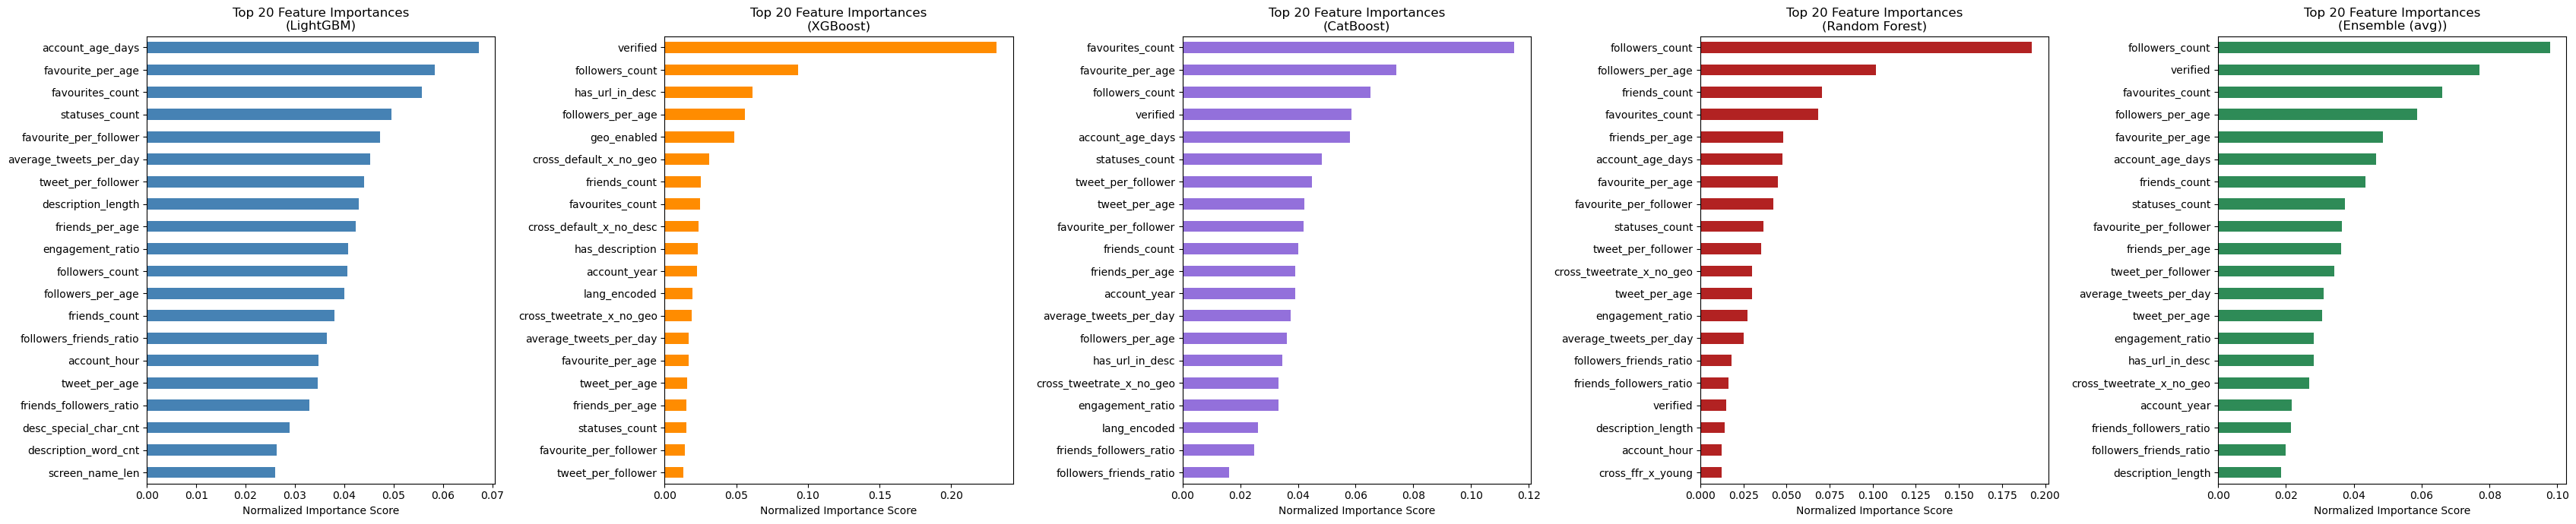

Rank   LightGBM                     XGBoost                      CatBoost                     Random Forest                Ensemble
-------------------------------------------------------------------------------------------------------------------------------------------------
1      account_age_days             verified                     favourites_count             followers_count              followers_count
2      favourite_per_age            followers_count              favourite_per_age            followers_per_age            verified
3      favourites_count             has_url_in_desc              followers_count              friends_count                favourites_count
4      statuses_count               followers_per_age            verified                     favourites_count             followers_per_age
5      favourite_per_follower       geo_enabled                  account_age_days             friends_per_age              favourite_per_age
6      average_tweets_per_day

In [27]:
# ── Re-train LightGBM on full train set ───────────────────────────────────────
lgb_full = lgb.LGBMClassifier(**{**lgb_params, 'n_estimators': 500})
lgb_full.fit(X, y)

# ── Re-train XGBoost on full train set ───────────────────────────────────────
xgb_params_full = {k: v for k, v in xgb_params.items() if k != 'early_stopping_rounds'}
xgb_full = xgb.XGBClassifier(**xgb_params_full)
xgb_full.fit(X, y)

# ── Re-train CatBoost on full train set ──────────────────────────────────────
cat_full = CatBoostClassifier(**{**cat_params, 'iterations': 500})
cat_full.fit(X, y)

# ── Re-train Random Forest on full train set ─────────────────────────────────
rf_full = RandomForestClassifier(**rf_params)
rf_full.fit(X, y)

# ── Get feature importances from each model ───────────────────────────────────
lgb_imp = pd.Series(lgb_full.feature_importances_, index=FEATURE_COLS)
xgb_imp = pd.Series(xgb_full.feature_importances_, index=FEATURE_COLS)
cat_imp = pd.Series(cat_full.get_feature_importance(), index=FEATURE_COLS)
rf_imp  = pd.Series(rf_full.feature_importances_,  index=FEATURE_COLS)

# ── Normalize each to 0-1 scale before averaging (fair comparison) ────────────
lgb_imp_norm = lgb_imp / lgb_imp.sum()
xgb_imp_norm = xgb_imp / xgb_imp.sum()
cat_imp_norm = cat_imp / cat_imp.sum()
rf_imp_norm  = rf_imp  / rf_imp.sum()

# ── Average all four = Ensemble importance ────────────────────────────────────
ensemble_imp = (lgb_imp_norm + xgb_imp_norm + cat_imp_norm + rf_imp_norm) / 4

# ── Plot all five side by side ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(34, 7))

for ax, imp, title, color in zip(
    axes,
    [lgb_imp_norm, xgb_imp_norm, cat_imp_norm, rf_imp_norm, ensemble_imp],
    ['LightGBM', 'XGBoost', 'CatBoost', 'Random Forest', 'Ensemble (avg)'],
    ['steelblue', 'darkorange', 'mediumpurple', 'firebrick', 'seagreen']
):
    top20 = imp.sort_values(ascending=False).head(20)
    top20.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Top 20 Feature Importances\n({title})', fontsize=12)
    ax.set_xlabel('Normalized Importance Score')

plt.tight_layout()
plt.show()

# ── Print top 10 comparison table ─────────────────────────────────────────────
print(f'{"Rank":<6} {"LightGBM":<28} {"XGBoost":<28} {"CatBoost":<28} {"Random Forest":<28} {"Ensemble"}')
print('-' * 145)
lgb_top = lgb_imp_norm.sort_values(ascending=False).head(10)
xgb_top = xgb_imp_norm.sort_values(ascending=False).head(10)
cat_top = cat_imp_norm.sort_values(ascending=False).head(10)
rf_top  = rf_imp_norm.sort_values(ascending=False).head(10)
ens_top = ensemble_imp.sort_values(ascending=False).head(10)
for i, (l, x, c, r, e) in enumerate(zip(lgb_top.index, xgb_top.index, cat_top.index, rf_top.index, ens_top.index), 1):
    print(f'{i:<6} {l:<28} {x:<28} {c:<28} {r:<28} {e}')

## 9. ROC Curve

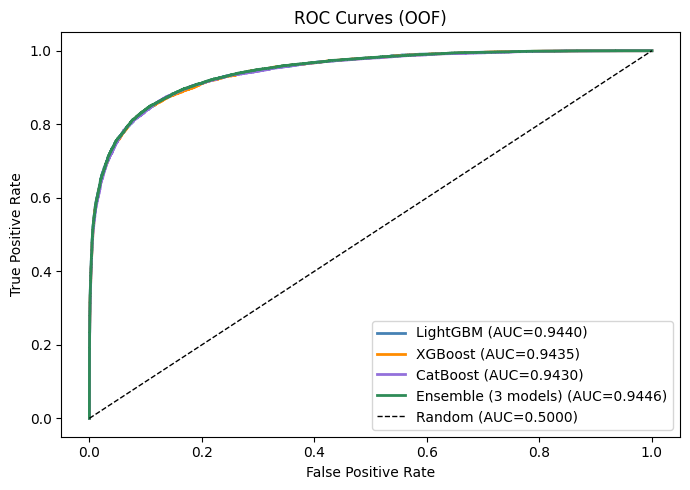

In [33]:
plt.figure(figsize=(7, 5))

for name, oof, color in [
    ('LightGBM',          lgb_oof,      'steelblue'),
    ('XGBoost',           xgb_oof,      'darkorange'),
    ('CatBoost',          cat_oof,      'mediumpurple'),
    ('Ensemble (3 models)', ensemble_oof, 'seagreen'),
]:
    fpr, tpr, _ = roc_curve(y, oof)
    auc = roc_auc_score(y, oof)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5000)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (OOF)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Generate Submission File

In [25]:
import os
from datetime import datetime

# ── Create submission folder if it doesn't exist ─────────────────────────────
os.makedirs('submission', exist_ok=True)  # won't crash if folder already exists

# ── Get today's date ──────────────────────────────────────────────────────────
today = datetime.today().strftime('%Y%m%d')  # e.g. 20260509

# ── Auto-increment version based on existing files in submission folder ───────
version = 1
while os.path.exists(f'submission/{today}_submission_v{version}.csv'):
    version += 1  # keep incrementing until filename doesn't exist yet

filename = f'submission/{today}_submission_v{version}.csv'  # e.g. submission/20260509_submission_v1.csv

# ── Create and save submission ────────────────────────────────────────────────
submission = pd.DataFrame({
    'index':  test_fe['index'],
    'target': ensemble_preds
})

submission.to_csv(filename, index=False)
print(f'Submission saved to {filename}')
submission.head(10)

Submission saved to submission/20260513_submission_v1.csv


,index,target
0,0,0.018946
1,1,0.870548
2,2,0.038842
3,3,0.037133
4,4,0.989056
5,5,0.005185
6,6,0.950138
7,7,0.163809
8,8,0.027822
9,9,0.942846


Blend  two best submissions

In [ ]:
# Read two best submission files
sub1 = pd.read_csv('submission/20260513_submission_v1_944753_93894.csv') 
sub2 = pd.read_csv('submission/20260512_submission_v1_944595_93887.csv') 

# Average them
blended = pd.DataFrame({
    'index':  sub1['index'],
    'target': (sub1['target'] + sub2['target']) / 2
})

blended.to_csv('submission/blended_submission.csv', index=False)
print('Blended submission saved')

Blended submission saved
